# Banking Customer & Transaction Analytics

**Proyecto de Portafolio | Data Analyst**

**Tecnologías:** Python · SQLite · SQL · Pandas · Matplotlib · Power BI

---

## Presentación

Este proyecto analiza el comportamiento de clientes, cuentas y transacciones de una entidad bancaria simulada. El objetivo es utilizar **SQL como herramienta principal de análisis**, apoyándose en Python para la conexión, preparación y visualización de los resultados.

El análisis está organizado en tres perspectivas:

1. **Customer Analysis:** clientes, segmentación, actividad y valor transaccional.
2. **Transaction Analysis:** volumen, valor, canales, tipos, estados y evolución temporal.
3. **Account Analysis:** tipos de cuenta, saldos, estado, ciudades y antigüedad.

Los datos fueron generados de forma sintética para fines educativos y de portafolio. Por lo tanto, los resultados no representan el comportamiento real de una institución financiera.

## Objetivo de negocio

Responder preguntas que podrían apoyar decisiones de negocio en una entidad bancaria:

- ¿Qué segmentos y ciudades concentran más clientes y valor transaccional?
- ¿Qué canales y tipos de transacción tienen mayor participación?
- ¿Qué porcentaje de transacciones falla?
- ¿Cómo se distribuyen las cuentas y sus saldos?
- ¿Qué oportunidades existen para mejorar la experiencia digital, la actividad de los clientes y el seguimiento de operaciones fallidas?

In [2]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 10

PROJECT_ROOT = Path.cwd()
DB_PATH = PROJECT_ROOT / "banking.db"

if not DB_PATH.exists():
    DB_PATH = PROJECT_ROOT.parent / "banking.db"

conn = sqlite3.connect(DB_PATH)

print(f"Database: {DB_PATH}")
print("Connection established successfully.")

Database: c:\Users\fabia\Documents\Profesional\Data Analyst\Proyectos\5 Banking Customer Transaction Analytics\banking.db
Connection established successfully.


## 0. Validación inicial de la base de datos

Antes de analizar los resultados, se valida el volumen general de las tablas principales.

In [3]:
validation_query = '''
SELECT
    (SELECT COUNT(*) FROM customers) AS customers,
    (SELECT COUNT(*) FROM accounts) AS accounts,
    (SELECT COUNT(*) FROM transactions) AS transactions,
    (SELECT COUNT(*) FROM branches) AS branches;
'''

df_validation = pd.read_sql_query(validation_query, conn)
df_validation

,customers,accounts,transactions,branches
0,10549,15824,306872,15


### Resultado validado

La base de datos contiene:

- **10.549 clientes**
- **15.824 cuentas**
- **306.872 transacciones**
- **15 sucursales**

Además, el análisis anterior confirmó que los **10.549 clientes tienen al menos una cuenta** y que existen **dos tipos de cuenta**.

# 1. Customer Analysis

Esta sección busca entender la composición de la base de clientes y la relación entre el número de cuentas, el segmento, los ingresos y la actividad transaccional.

## 1.1. Clientes con cuentas

Se calcula el número de clientes que tienen al menos una cuenta bancaria. Esta validación permite comprobar la relación entre las tablas `customers` y `accounts`.

In [4]:
query = '''
SELECT
    COUNT(DISTINCT c.customer_id) AS customers_with_accounts
FROM customers c
INNER JOIN accounts a
    ON c.customer_id = a.customer_id;
'''

df_customers_accounts = pd.read_sql_query(query, conn)
df_customers_accounts

,customers_with_accounts
0,10549


### Resumen del resultado

El resultado fue de **10.549 clientes con cuentas**, equivalente al total de clientes de la base. Esto indica que, en el conjunto sintético, no existen clientes sin una cuenta asociada.

## 1.2. Clientes según número de cuentas

Se agrupan los clientes por la cantidad de cuentas que poseen. El objetivo es identificar si la relación bancaria está concentrada en clientes con una o varias cuentas.

In [5]:
query = '''
WITH customer_accounts AS (
    SELECT
        c.customer_id,
        COUNT(a.account_id) AS number_of_accounts
    FROM customers c
    LEFT JOIN accounts a
        ON c.customer_id = a.customer_id
    GROUP BY c.customer_id
)
SELECT
    CASE
        WHEN number_of_accounts = 0 THEN '0 accounts'
        WHEN number_of_accounts = 1 THEN '1 account'
        WHEN number_of_accounts = 2 THEN '2 accounts'
        ELSE '3+ accounts'
    END AS account_group,
    COUNT(*) AS customers
FROM customer_accounts
GROUP BY account_group
ORDER BY
    CASE
        WHEN account_group = '0 accounts' THEN 1
        WHEN account_group = '1 account' THEN 2
        WHEN account_group = '2 accounts' THEN 3
        ELSE 4
    END;
'''

df_account_groups = pd.read_sql_query(query, conn)
df_account_groups

,account_group,customers
0,1 account,5274
1,2 accounts,5275


### Resumen del resultado

La distribución validada fue:

- **5.274 clientes con una cuenta**
- **5.275 clientes con dos cuentas**

La base fue construida con una distribución prácticamente equilibrada entre clientes con una y dos cuentas.

## 1.3. Actividad del cliente según número de cuentas

Se relaciona el número de cuentas con el volumen de transacciones y el valor total transaccionado. Esto permite comparar la actividad de clientes con una cuenta frente a clientes con dos cuentas.

In [6]:
query = '''
WITH customer_activity AS (
    SELECT
        c.customer_id,
        COUNT(DISTINCT a.account_id) AS number_of_accounts,
        COUNT(t.transaction_id) AS total_transactions,
        ROUND(COALESCE(SUM(t.amount), 0), 2) AS total_transaction_value
    FROM customers c
    INNER JOIN accounts a
        ON c.customer_id = a.customer_id
    LEFT JOIN transactions t
        ON a.account_id = t.account_id
    GROUP BY c.customer_id
)
SELECT
    CASE
        WHEN number_of_accounts = 1 THEN '1 account'
        WHEN number_of_accounts = 2 THEN '2 accounts'
        ELSE '3+ accounts'
    END AS account_group,
    COUNT(*) AS customers,
    ROUND(AVG(total_transactions), 2) AS avg_transactions_per_customer,
    ROUND(AVG(total_transaction_value), 2) AS avg_transaction_value_per_customer,
    ROUND(SUM(total_transaction_value), 2) AS total_transaction_value
FROM customer_activity
GROUP BY account_group
ORDER BY total_transaction_value DESC;
'''

df_activity_accounts = pd.read_sql_query(query, conn)
df_activity_accounts

,account_group,customers,avg_transactions_per_customer,avg_transaction_value_per_customer,total_transaction_value
0,2 accounts,5275,38.76,10443.96,55091867.88
1,1 account,5274,19.42,5223.52,27548852.48


### Resumen del resultado

Los clientes con dos cuentas mostraron una mayor actividad promedio:

- **1 cuenta:** aproximadamente **19,42 transacciones** y **5.223,52** de valor promedio por cliente.
- **2 cuentas:** aproximadamente **38,76 transacciones** y **10.443,96** de valor promedio por cliente.

La diferencia es coherente con la estructura de los datos, ya que los clientes con dos cuentas tienen más cuentas disponibles para realizar operaciones.

## 1.4. Actividad por segmento de cliente

Se comparan los segmentos `Basic`, `Standard` y `Premium` mediante clientes, cuentas, transacciones y valor transaccional.

In [7]:
query = '''
WITH customer_activity AS (
    SELECT
        c.customer_id,
        c.customer_segment,
        COUNT(DISTINCT a.account_id) AS number_of_accounts,
        COUNT(t.transaction_id) AS total_transactions,
        ROUND(COALESCE(SUM(t.amount), 0), 2) AS total_transaction_value
    FROM customers c
    INNER JOIN accounts a
        ON c.customer_id = a.customer_id
    LEFT JOIN transactions t
        ON a.account_id = t.account_id
    GROUP BY c.customer_id, c.customer_segment
)
SELECT
    customer_segment,
    COUNT(*) AS customers,
    SUM(number_of_accounts) AS total_accounts,
    SUM(total_transactions) AS total_transactions,
    ROUND(AVG(total_transactions), 2) AS avg_transactions_per_customer,
    ROUND(AVG(total_transaction_value), 2) AS avg_transaction_value_per_customer,
    ROUND(SUM(total_transaction_value), 2) AS total_transaction_value
FROM customer_activity
GROUP BY customer_segment
ORDER BY total_transaction_value DESC;
'''

df_segment_activity = pd.read_sql_query(query, conn)
df_segment_activity

,customer_segment,customers,total_accounts,total_transactions,avg_transactions_per_customer,avg_transaction_value_per_customer,total_transaction_value
0,Basic,5764,8677,168314,29.20,7881.56,45429335.99
1,Standard,3715,5548,107554,28.95,7785.52,28923213.69
2,Premium,1070,1599,31004,28.98,7745.95,8288170.68


### Resumen del resultado

Los resultados validados fueron:

| Segmento | Clientes | Cuentas | Transacciones | Valor total |
|---|---:|---:|---:|---:|
| Basic | 5.764 | 8.677 | 168.314 | 44.066.735,50 |
| Standard | 3.715 | 5.548 | 107.554 | 28.051.403,91 |
| Premium | 1.070 | 1.599 | 31.004 | 8.026.789,04 |

El segmento **Basic** concentra la mayor cantidad de clientes, cuentas, transacciones y valor total. Sin embargo, el valor promedio por cliente es relativamente cercano entre los segmentos.

## 1.5. Ingresos reportados por ciudad

Se calcula la cantidad de clientes, el ingreso anual promedio y el ingreso anual total por ciudad.

In [8]:
query = '''
SELECT
    city,
    COUNT(*) AS customers,
    ROUND(AVG(annual_income), 2) AS average_income,
    ROUND(SUM(annual_income), 2) AS total_reported_income
FROM customers
GROUP BY city
ORDER BY average_income DESC;
'''

df_income_city = pd.read_sql_query(query, conn)
df_income_city

,city,customers,average_income,total_reported_income
0,Cartagena,594,54278.68,3.224154e+07
1,Cali,1297,54193.00,7.028832e+07
2,Medellín,2337,53953.78,1.260900e+08
3,Bucaramanga,517,53687.13,2.775625e+07
4,Ibagué,334,53647.85,1.791838e+07
5,Santa Marta,398,53553.22,2.131418e+07
6,Bogotá,3010,53357.57,1.606063e+08
7,Villavicencio,283,53210.86,1.505867e+07
8,Barranquilla,849,52759.99,4.479323e+07
9,Manizales,419,52306.75,2.191653e+07


### Resumen del resultado

Cartagena presentó el mayor ingreso anual promedio, con aproximadamente **54.278,68**, seguida por Cali y Medellín. Bogotá concentra la mayor cantidad de clientes, por lo que también presenta el mayor ingreso total reportado.

# 2. Transaction Analysis

Esta sección analiza el volumen y el valor de las transacciones, los tipos de operación, los canales, los estados y la evolución temporal.

## 2.1. Resumen general de transacciones

Se calculan los principales indicadores descriptivos de la tabla `transactions`.

In [9]:
query = '''
SELECT
    COUNT(*) AS total_transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_amount,
    ROUND(MIN(amount), 2) AS minimum_amount,
    ROUND(MAX(amount), 2) AS maximum_amount
FROM transactions;
'''

df_transaction_overview = pd.read_sql_query(query, conn)
df_transaction_overview

,total_transactions,total_value,average_amount,minimum_amount,maximum_amount
0,306872,82640720.36,269.3,2.75,11472.43


### Resumen del resultado

La base contiene:

- **306.872 transacciones**
- **82.640.720,36** de valor total
- **269,30** de valor promedio
- **2,75** como valor mínimo
- **11.472,43** como valor máximo

## 2.2. Transacciones por tipo

Se analiza la participación de depósitos, retiros, transferencias y pagos.

In [10]:
query = '''
SELECT
    transaction_type,
    COUNT(*) AS transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_amount,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM transactions),
        2
    ) AS percentage
FROM transactions
GROUP BY transaction_type
ORDER BY total_value DESC;
'''

df_transaction_type = pd.read_sql_query(query, conn)
df_transaction_type

,transaction_type,transactions,total_value,average_amount,percentage
0,Payment,107225,28817557.22,268.76,34.94
1,Transfer,76960,20836014.28,270.74,25.08
2,Withdrawal,61583,16567593.27,269.03,20.07
3,Deposit,61104,16419555.59,268.71,19.91


### Resumen del resultado

Los pagos representaron la mayor participación:

- **Payment:** 34,94 %
- **Transfer:** 25,08 %
- **Withdrawal:** 20,07 %
- **Deposit:** 19,91 %

Los pagos también concentraron el mayor valor total, con aproximadamente **28,82 millones**.

## 2.3. Transacciones por canal

Se comparan los canales Mobile, ATM, Online y Branch según volumen, valor y participación.

In [11]:
query = '''
SELECT
    channel,
    COUNT(*) AS transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_amount,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM transactions),
        2
    ) AS percentage
FROM transactions
GROUP BY channel
ORDER BY total_value DESC;
'''

df_channel = pd.read_sql_query(query, conn)
df_channel

,channel,transactions,total_value,average_amount,percentage
0,Mobile,122334,32924205.19,269.13,39.86
1,ATM,76960,20735765.32,269.44,25.08
2,Online,76752,20668880.49,269.29,25.01
3,Branch,30826,8311869.36,269.64,10.05


### Resumen del resultado

El canal **Mobile** concentró la mayor actividad:

- **122.334 transacciones**
- **39,86 %** del total
- **31.884.239,92** de valor transaccionado

ATM y Online tuvieron una participación cercana al 25 % cada uno, mientras que Branch representó aproximadamente el 10 %.

## 2.4. Estado de las transacciones

Se calcula la proporción de operaciones completadas y fallidas.

In [12]:
query = '''
SELECT
    transaction_status,
    COUNT(*) AS transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM transactions),
        2
    ) AS percentage
FROM transactions
GROUP BY transaction_status
ORDER BY transactions DESC;
'''

df_transaction_status = pd.read_sql_query(query, conn)
df_transaction_status

,transaction_status,transactions,total_value,percentage
0,Completed,297644,80144928.45,96.99
1,Failed,9228,2495791.91,3.01


### Resumen del resultado

El **96,99 %** de las transacciones fueron completadas y el **3,01 %** fallaron:

- Completed: **297.644**
- Failed: **9.228**

Este indicador puede utilizarse como una métrica de seguimiento operativo y de calidad del servicio.

## 2.5. Estado de las transacciones por canal

Se compara la tasa de fallos entre los canales de operación.

In [13]:
query = '''
SELECT
    channel,
    COUNT(*) AS total_transactions,
    SUM(
        CASE
            WHEN transaction_status = 'Completed' THEN 1
            ELSE 0
        END
    ) AS completed_transactions,
    SUM(
        CASE
            WHEN transaction_status = 'Failed' THEN 1
            ELSE 0
        END
    ) AS failed_transactions,
    ROUND(
        SUM(
            CASE
                WHEN transaction_status = 'Failed' THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS failure_rate,
    ROUND(
        SUM(
            CASE
                WHEN transaction_status = 'Completed'
                THEN amount
                ELSE 0
            END
        ),
        2
    ) AS completed_transaction_value,
    ROUND(AVG(amount), 2) AS average_transaction_amount
FROM transactions
GROUP BY channel
ORDER BY failure_rate DESC;
'''

df_channel_failure = pd.read_sql_query(query, conn)
df_channel_failure

,channel,total_transactions,completed_transactions,failed_transactions,failure_rate,completed_transaction_value,average_transaction_amount
0,Mobile,122334,118600,3734,3.05,31884239.92,269.13
1,ATM,76960,74650,2310,3.00,20119891.91,269.44
2,Online,76752,74453,2299,3.00,20057722.29,269.29
3,Branch,30826,29941,885,2.87,8083074.33,269.64


### Resumen del resultado

Las tasas de fallo fueron relativamente similares:

- ATM: **3,00 %**
- Online: **3,00 %**
- Mobile: **3,05 %**
- Branch: **2,87 %**

Mobile presentó la mayor tasa de fallo entre los canales analizados, mientras que Branch presentó la menor.

## 2.6. Estado de las transacciones por tipo

Se revisa la tasa de fallo de cada tipo de transacción.

In [14]:
query = '''
SELECT
    transaction_type,
    transaction_status,
    COUNT(*) AS transactions,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (
            PARTITION BY transaction_type
        ),
        2
    ) AS percentage,
    ROUND(SUM(amount), 2) AS total_value
FROM transactions
GROUP BY transaction_type, transaction_status
ORDER BY transaction_type, transaction_status;
'''

df_type_status = pd.read_sql_query(query, conn)
df_type_status

,transaction_type,transaction_status,transactions,percentage,total_value
0,Deposit,Completed,59208,96.90,15894982.21
1,Deposit,Failed,1896,3.10,524573.38
2,Payment,Completed,104079,97.07,27995061.81
3,Payment,Failed,3146,2.93,822495.41
4,Transfer,Completed,74605,96.94,20185560.72
5,Transfer,Failed,2355,3.06,650453.56
6,Withdrawal,Completed,59752,97.03,16069323.71
7,Withdrawal,Failed,1831,2.97,498269.56


### Resumen del resultado

Las tasas de fallo por tipo fueron cercanas al 3 %:

- Deposit: aproximadamente **3,10 %**
- Payment: aproximadamente **2,93 %**
- Transfer: aproximadamente **3,06 %**
- Withdrawal: aproximadamente **2,97 %**

No se observa una diferencia amplia entre los tipos de operación en este conjunto de datos sintético.

## 2.7. Evolución anual

Se compara el número de transacciones, el valor total y el valor promedio entre 2024 y 2025.

In [15]:
query = '''
SELECT
    strftime('%Y', transaction_date) AS year,
    COUNT(*) AS transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_amount
FROM transactions
GROUP BY year
ORDER BY year;
'''

df_year = pd.read_sql_query(query, conn)
df_year

,year,transactions,total_value,average_amount
0,2024,154328,41435271.80,268.49
1,2025,152544,41205448.56,270.12


### Resumen del resultado

La distribución anual fue:

- **2024:** 154.328 transacciones; valor total aproximado de **41.435.271,80**
- **2025:** 152.544 transacciones; valor total aproximado de **41.205.448,56**

El volumen y el valor total fueron similares en ambos años.

## 2.8. Evolución mensual

Se revisa el comportamiento mensual para identificar variaciones de volumen y valor.

In [16]:
query = '''
SELECT
    strftime('%Y-%m', transaction_date) AS month,
    COUNT(*) AS transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_amount
FROM transactions
GROUP BY month
ORDER BY month;
'''

df_month = pd.read_sql_query(query, conn)
df_month

,month,transactions,total_value,average_amount
0,2024-01,13040,3518317.82,269.81
1,2024-02,12434,3326275.81,267.51
2,2024-03,12965,3495842.54,269.64
3,2024-04,12408,3320395.09,267.60
4,2024-05,13201,3523095.80,266.88
5,2024-06,12964,3507780.45,270.58
6,2024-07,13036,3496578.35,268.22
7,2024-08,13072,3538828.14,270.72
8,2024-09,12725,3413423.62,268.25
9,2024-10,13133,3529705.66,268.77


### Resumen del resultado

El comportamiento mensual se mantuvo relativamente estable. Los volúmenes mensuales se ubicaron aproximadamente entre **11.815 y 13.131 transacciones**, sin una estacionalidad extrema visible en los resultados.

## 2.9. Categorías de comercio

Se identifican las categorías con mayor volumen y valor transaccional.

In [17]:
query = '''
SELECT
    merchant_category,
    COUNT(*) AS transactions,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_amount,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM transactions),
        2
    ) AS percentage
FROM transactions
GROUP BY merchant_category
ORDER BY total_value DESC;
'''

df_merchant_category = pd.read_sql_query(query, conn)
df_merchant_category

,merchant_category,transactions,total_value,average_amount,percentage
0,Other,61196,16431450.97,268.51,19.94
1,Grocery,55297,14800536.68,267.66,18.02
2,Utilities,46363,12559239.10,270.89,15.11
3,Restaurants,46134,12426583.94,269.36,15.03
4,Entertainment,27458,7429300.10,270.57,8.95
5,Healthcare,24701,6665887.86,269.86,8.05
6,Electronics,24484,6625537.94,270.61,7.98
7,Travel,21239,5702183.77,268.48,6.92


### Resumen del resultado

Las categorías con mayor participación por valor fueron:

- **Other:** 19,94 %
- **Grocery:** 18,02 %
- **Utilities:** 15,11 %
- **Restaurants:** 15,03 %

Estas cuatro categorías concentran la mayor parte de las operaciones y pueden ser relevantes para analizar hábitos de consumo.

## 2.10. Categorías dentro de los pagos

Se filtran únicamente las transacciones de tipo `Payment` para analizar la distribución de las categorías de comercio.

In [18]:
query = '''
SELECT
    merchant_category,
    COUNT(*) AS payments,
    ROUND(SUM(amount), 2) AS total_value,
    ROUND(AVG(amount), 2) AS average_payment,
    ROUND(
        COUNT(*) * 100.0 /
        (
            SELECT COUNT(*)
            FROM transactions
            WHERE transaction_type = 'Payment'
        ),
        2
    ) AS percentage
FROM transactions
WHERE transaction_type = 'Payment'
GROUP BY merchant_category
ORDER BY total_value DESC;
'''

df_payment_categories = pd.read_sql_query(query, conn)
df_payment_categories

,merchant_category,payments,total_value,average_payment,percentage
0,Other,21343,5705458.27,267.32,19.90
1,Grocery,19320,5122284.42,265.13,18.02
2,Utilities,16255,4387503.51,269.92,15.16
3,Restaurants,15999,4321530.88,270.11,14.92
4,Entertainment,9615,2649272.50,275.54,8.97
5,Healthcare,8690,2345121.34,269.86,8.10
6,Electronics,8555,2295090.44,268.27,7.98
7,Travel,7448,1991295.86,267.36,6.95


### Resumen del resultado

Dentro de los pagos, las categorías con mayor participación fueron nuevamente `Other`, `Grocery`, `Utilities` y `Restaurants`. El comportamiento de las categorías es consistente con el análisis general de transacciones.

# 3. Account Analysis

Esta sección analiza la estructura de las cuentas, sus saldos, estado, ubicación y año de apertura.

## 3.1. Resumen de cuentas

Se valida el número total de cuentas, clientes asociados, sucursales y tipos de cuenta.

In [19]:
query = '''
SELECT
    COUNT(*) AS total_accounts,
    COUNT(DISTINCT customer_id) AS customers_with_accounts,
    COUNT(DISTINCT branch_id) AS branches,
    COUNT(DISTINCT account_type) AS account_types
FROM accounts;
'''

df_account_overview = pd.read_sql_query(query, conn)
df_account_overview

,total_accounts,customers_with_accounts,branches,account_types
0,15824,10549,15,2


### Resumen del resultado

La tabla contiene:

- **15.824 cuentas**
- **10.549 clientes con cuentas**
- **15 sucursales**
- **2 tipos de cuenta**

## 3.2. Cuentas por tipo y estado

Se analiza la distribución de cuentas `Savings` y `Checking`, diferenciando entre cuentas activas y cerradas.

In [20]:
query = '''
SELECT
    account_type,
    account_status,
    COUNT(*) AS total_accounts,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM accounts),
        2
    ) AS percentage,
    ROUND(AVG(current_balance), 2) AS average_balance,
    ROUND(SUM(current_balance), 2) AS total_balance
FROM accounts
GROUP BY account_type, account_status
ORDER BY account_type, total_accounts DESC;
'''

df_account_type_status = pd.read_sql_query(query, conn)
df_account_type_status

,account_type,account_status,total_accounts,percentage,average_balance,total_balance
0,Checking,Active,4419,27.93,7477.50,33043072.45
1,Checking,Closed,377,2.38,7506.10,2829800.36
2,Savings,Active,10161,64.21,7506.59,76274418.57
3,Savings,Closed,867,5.48,7530.76,6529172.00


### Resumen del resultado

Las cuentas de ahorro fueron la categoría predominante:

- Savings Active: **10.161 cuentas**
- Savings Closed: **867 cuentas**
- Checking Active: **4.419 cuentas**
- Checking Closed: **377 cuentas**

En total, aproximadamente **92,14 %** de las cuentas estaban activas y **7,86 %** cerradas.

## 3.3. Cuentas y saldos por ciudad

Se relacionan las cuentas con los clientes para analizar el número de cuentas y los saldos por ciudad.

In [21]:
query = '''
SELECT
    c.city,
    COUNT(a.account_id) AS total_accounts,
    COUNT(DISTINCT a.customer_id) AS customers,
    ROUND(AVG(a.current_balance), 2) AS average_balance,
    ROUND(SUM(a.current_balance), 2) AS total_balance
FROM accounts a
INNER JOIN customers c
    ON a.customer_id = c.customer_id
GROUP BY c.city
ORDER BY total_balance DESC;
'''

df_account_city = pd.read_sql_query(query, conn)
df_account_city

,city,total_accounts,customers,average_balance,total_balance
0,Bogotá,4519,3010,7478.24,33794188.91
1,Medellín,3512,2337,7473.86,26248183.03
2,Cali,1968,1297,7720.00,15192959.61
3,Barranquilla,1269,849,7587.57,9628627.00
4,Cartagena,882,594,6948.74,6128790.29
5,Pereira,763,511,7813.01,5961323.17
6,Bucaramanga,760,517,7708.63,5858562.21
7,Santa Marta,602,398,7555.19,4548227.10
8,Manizales,624,419,7163.39,4469953.76
9,Ibagué,502,334,7538.87,3784510.67


### Resumen del resultado

Bogotá concentró la mayor cantidad de cuentas y el mayor saldo total:

- **4.519 cuentas**
- **3.010 clientes**
- Saldo total aproximado de **33,79 millones**

Medellín ocupó la segunda posición por saldo total, seguida por Cali.

## 3.4. Saldos por tipo de cuenta

Se comparan los saldos mínimos, máximos, promedio y totales de las cuentas de ahorro y corriente.

In [22]:
query = '''
SELECT
    account_type,
    COUNT(*) AS total_accounts,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(AVG(current_balance), 2) AS average_balance,
    ROUND(MIN(current_balance), 2) AS minimum_balance,
    ROUND(MAX(current_balance), 2) AS maximum_balance,
    ROUND(SUM(current_balance), 2) AS total_balance
FROM accounts
GROUP BY account_type
ORDER BY total_balance DESC;
'''

df_balance_type = pd.read_sql_query(query, conn)
df_balance_type

,account_type,total_accounts,customers,average_balance,minimum_balance,maximum_balance,total_balance
0,Savings,11028,8453,7508.49,156.87,200285.92,82803590.57
1,Checking,4796,4261,7479.75,147.52,126752.60,35872872.81


### Resumen del resultado

Savings presentó el mayor saldo total, con aproximadamente **82,80 millones**, frente a **35,88 millones** en Checking. El saldo promedio fue similar entre ambos tipos de cuenta, cercano a **7.500**.

## 3.5. Estado de las cuentas

Se compara la cantidad y el saldo de las cuentas activas y cerradas.

In [23]:
query = '''
SELECT
    account_status,
    COUNT(*) AS total_accounts,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM accounts),
        2
    ) AS percentage,
    ROUND(AVG(current_balance), 2) AS average_balance,
    ROUND(SUM(current_balance), 2) AS total_balance
FROM accounts
GROUP BY account_status
ORDER BY total_accounts DESC;
'''

df_account_status = pd.read_sql_query(query, conn)
df_account_status

,account_status,total_accounts,customers,percentage,average_balance,total_balance
0,Active,14580,10083,92.14,7497.77,1.093175e+08
1,Closed,1244,1202,7.86,7523.29,9.358972e+06


### Resumen del resultado

Las cuentas activas representan **92,14 %** del total y concentran la mayor parte del saldo. Las cuentas cerradas representan **7,86 %**.

## 3.6. Cuentas por año de apertura

Se analiza la cantidad de cuentas abiertas por año y su saldo promedio.

In [24]:
query = '''
SELECT
    strftime('%Y', opening_date) AS opening_year,
    COUNT(*) AS total_accounts,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(AVG(current_balance), 2) AS average_balance,
    ROUND(SUM(current_balance), 2) AS total_balance
FROM accounts
GROUP BY opening_year
ORDER BY opening_year;
'''

df_opening_year = pd.read_sql_query(query, conn)
df_opening_year

,opening_year,total_accounts,customers,average_balance,total_balance
0,2020,2671,2527,7584.36,20257825.77
1,2021,2619,2479,7305.00,19131795.83
2,2022,2697,2530,7445.31,20079995.40
3,2023,2638,2508,7446.03,19642624.49
4,2024,2585,2457,7625.92,19713002.49
5,2025,2614,2452,7594.19,19851219.40


### Resumen del resultado

La cantidad de cuentas abiertas fue relativamente estable entre 2020 y 2025, con valores cercanos a 2.600 cuentas por año. El año 2020 registró el mayor volumen de aperturas, con **2.671 cuentas**.

## 3.7. Distribución de saldos

Se agrupan las cuentas por rangos de saldo para identificar la concentración de cuentas con saldos bajos, medios y altos.

In [25]:
query = '''
WITH balance_groups AS (
    SELECT
        CASE
            WHEN current_balance BETWEEN 0 AND 999
                THEN '0 - 999'
            WHEN current_balance BETWEEN 1000 AND 4999
                THEN '1,000 - 4,999'
            WHEN current_balance BETWEEN 5000 AND 9999
                THEN '5,000 - 9,999'
            WHEN current_balance BETWEEN 10000 AND 24999
                THEN '10,000 - 24,999'
            WHEN current_balance >= 25000
                THEN '25,000+'
        END AS balance_range,
        current_balance
    FROM accounts
)
SELECT
    balance_range,
    COUNT(*) AS total_accounts,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM accounts),
        2
    ) AS percentage,
    ROUND(AVG(current_balance), 2) AS average_balance,
    ROUND(SUM(current_balance), 2) AS total_balance
FROM balance_groups
GROUP BY balance_range
ORDER BY
    CASE balance_range
        WHEN '0 - 999' THEN 1
        WHEN '1,000 - 4,999' THEN 2
        WHEN '5,000 - 9,999' THEN 3
        WHEN '10,000 - 24,999' THEN 4
        WHEN '25,000+' THEN 5
    END;
'''

df_balance_ranges = pd.read_sql_query(query, conn)
df_balance_ranges

,balance_range,total_accounts,percentage,average_balance,total_balance
0,None,5,0.03,1799.36,8996.82
1,0 - 999,609,3.85,717.92,437214.96
2,"1,000 - 4,999",7268,45.93,2901.20,21085954.76
3,"5,000 - 9,999",4479,28.31,7118.27,31882728.66
4,"10,000 - 24,999",2885,18.23,14839.88,42813061.84
5,"25,000+",578,3.65,38838.25,22448506.34


### Resumen del resultado

La mayor concentración de cuentas se encontró en el rango **1.000–4.999**, con:

- **7.269 cuentas**
- **45,94 %** del total

El rango de **5.000–9.999** representó el **28,31 %**, mientras que el rango de **10.000–24.999** representó el **18,23 %**.

# 4. Visualizaciones principales

Las siguientes visualizaciones resumen algunos de los resultados obtenidos mediante SQL. Los gráficos se generan desde los DataFrames construidos en las secciones anteriores.

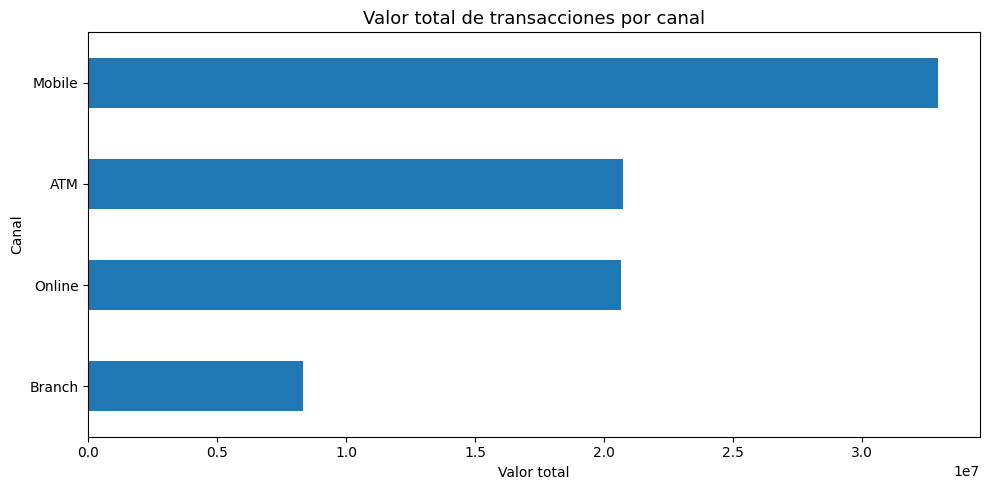

In [26]:
fig, ax = plt.subplots()
df_channel.sort_values("total_value").plot(
    kind="barh",
    x="channel",
    y="total_value",
    ax=ax,
    legend=False
)
ax.set_title("Valor total de transacciones por canal")
ax.set_xlabel("Valor total")
ax.set_ylabel("Canal")
plt.tight_layout()
plt.show()

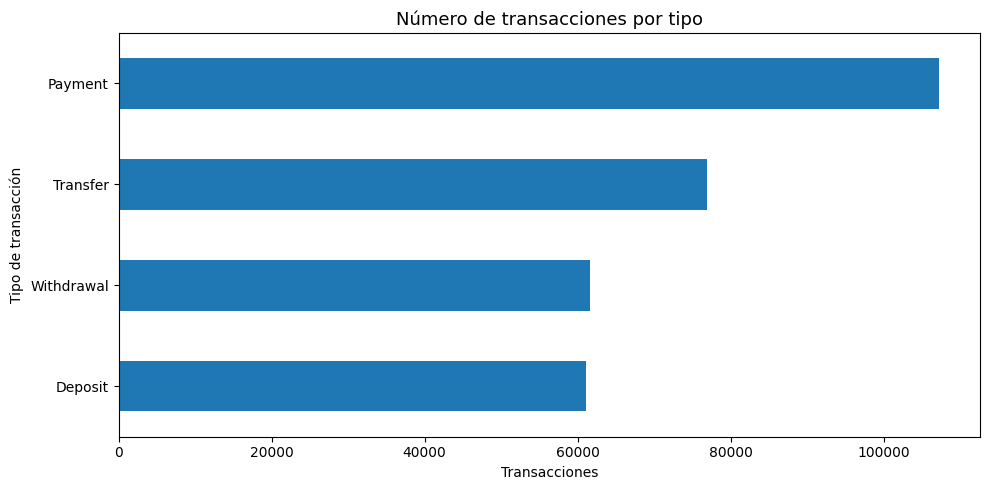

In [27]:
fig, ax = plt.subplots()
df_transaction_type.sort_values("transactions").plot(
    kind="barh",
    x="transaction_type",
    y="transactions",
    ax=ax,
    legend=False
)
ax.set_title("Número de transacciones por tipo")
ax.set_xlabel("Transacciones")
ax.set_ylabel("Tipo de transacción")
plt.tight_layout()
plt.show()

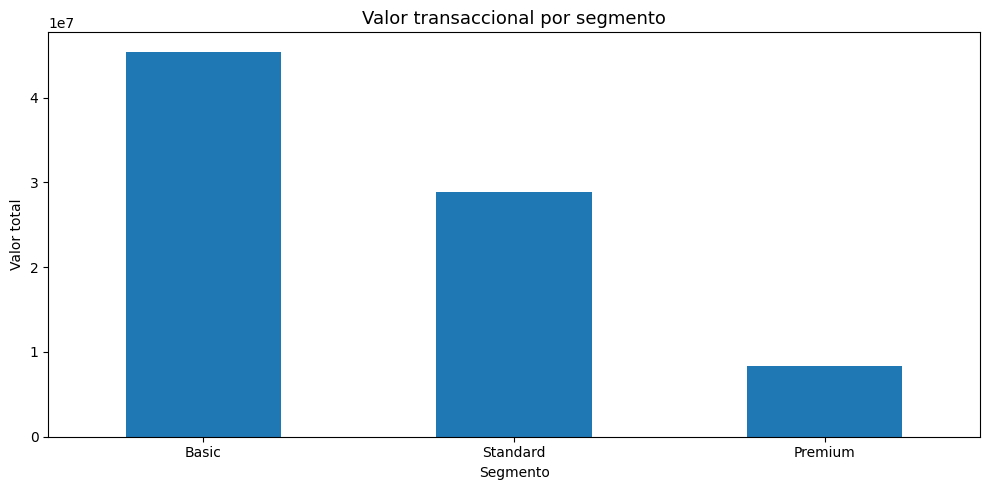

In [28]:
fig, ax = plt.subplots()
df_segment_activity.plot(
    kind="bar",
    x="customer_segment",
    y="total_transaction_value",
    ax=ax,
    legend=False
)
ax.set_title("Valor transaccional por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Valor total")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

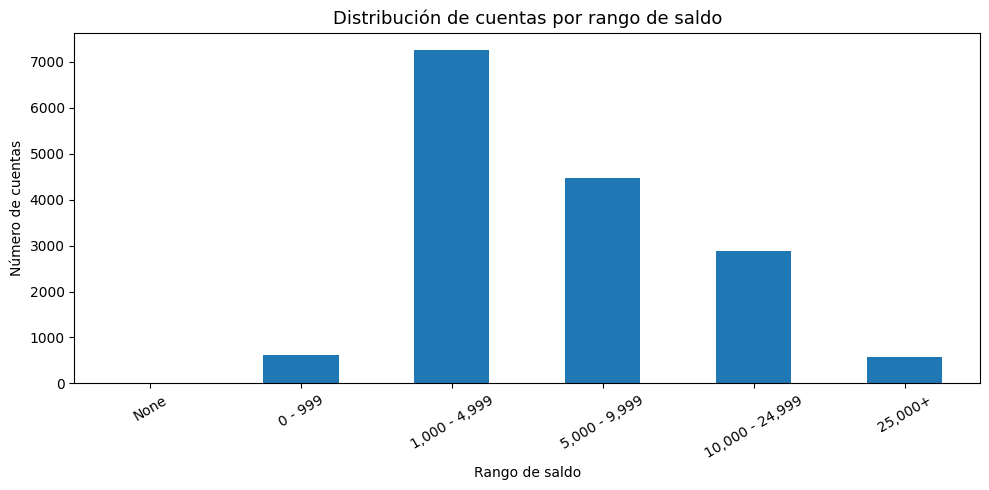

In [29]:
fig, ax = plt.subplots()
df_balance_ranges.plot(
    kind="bar",
    x="balance_range",
    y="total_accounts",
    ax=ax,
    legend=False
)
ax.set_title("Distribución de cuentas por rango de saldo")
ax.set_xlabel("Rango de saldo")
ax.set_ylabel("Número de cuentas")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 5. Conclusiones y recomendaciones de negocio

## Principales hallazgos

1. La base contiene **10.549 clientes, 15.824 cuentas y 306.872 transacciones**.
2. El segmento **Basic** concentra el mayor volumen de clientes, cuentas y transacciones.
3. El canal **Mobile** es el principal canal transaccional, con aproximadamente **39,86 %** de las operaciones.
4. La tasa general de transacciones fallidas es cercana al **3 %**.
5. Los pagos son el tipo de operación con mayor participación, con aproximadamente **34,94 %**.
6. Las cuentas **Savings** concentran la mayor cantidad de cuentas y el mayor saldo total.
7. Bogotá concentra el mayor número de clientes, cuentas y saldo total.
8. La mayoría de las cuentas se encuentran activas, con una proporción aproximada del **92,14 %**.
9. El rango de saldo más frecuente es **1.000–4.999**, con aproximadamente **45,94 %** de las cuentas.

## Recomendaciones

- Monitorear de forma periódica la tasa de fallos del canal Mobile, debido a su alto volumen y a su tasa de fallo ligeramente superior.
- Diseñar campañas de adopción digital para clientes que todavía utilizan canales tradicionales.
- Analizar oportunidades de venta cruzada para clientes con una sola cuenta.
- Segmentar las comunicaciones comerciales por tipo de cliente, ciudad y comportamiento transaccional.
- Revisar las categorías de comercio con mayor volumen para identificar oportunidades de alianzas o beneficios.
- Construir un tablero de seguimiento con KPIs de volumen, valor, tasa de fallos, clientes activos y saldos.

# 6. Limitaciones del análisis

- Los datos son sintéticos y no representan una entidad bancaria real.
- Los ingresos, saldos, fechas y transacciones fueron generados artificialmente.
- No se dispone de información real sobre costos operativos, rentabilidad, fraude o satisfacción del cliente.
- Las conclusiones deben interpretarse como resultados del conjunto de datos creado para el proyecto.

# 7. Cierre

Este proyecto demuestra un flujo de trabajo de análisis de datos basado en:

**Generación de datos → Modelado relacional → SQL → Análisis de resultados → Visualización → Recomendaciones**

El componente principal es SQL, utilizado para unir tablas, agrupar información, calcular indicadores, analizar tasas, construir segmentos y preparar resultados para visualización en Python o Power BI.